# Algerian Darija $\leftrightarrow$ English Translation Dataset Cleaning & Preprocessing

This notebook performs end-to-end data cleaning, quality assurance, consistency correction, tokenizer analysis, and prompt template formatting for the **Algerian Darija $\leftrightarrow$ English Translation Dataset** (`algerian_translation_50k.csv`).

### Preprocessing Objectives & Pipeline:
1. **Environment Setup & Configuration**: Load libraries, configuration, and Hugging Face authentication.
2. **Data Ingestion & Initial EDA**: Inspect schema, dimensions, nulls, and sample rows.
3. **Stage 1: Standard Cleaning**: Eliminate duplicate translation pairs, empty strings, and whitespace anomalies with detailed telemetry.
4. **Stage 2: Square Bracket Substring Removal (`[...]`)**: Detect and strip acoustic/meta tags (e.g. `[Music]`, `[موسيقى]`, `[applause]`) strictly when they co-occur in both Arabic and English columns for a given sample.
5. **Stage 3: Systematic Inconsistency Audit (Algerian vs. Egyptian Terms)**: Audit and detect geographic and currency mismatches (e.g., *Egypt*, *Cairo*, *pound* vs Algerian references), evaluate occurrence thresholds, and drop inconsistent samples.
6. **Stage 4: Gemma 4 Tokenizer & Translation Prompt Template Modeling**: Load `google/gemma-4-E2B` tokenizer, implement bidirectional SFT translation instruction templates, and compute full template token lengths.
7. **Stage 5: Token Length Distribution & Statistical Analysis**: Empirically evaluate sequence lengths and percentiles with visual histograms.
8. **Stage 6: Long Sequence Splitting**: Identify examples exceeding the target max sequence length and split multi-sentence/paragraph parallel texts along aligned boundaries to guarantee context compliance without losing valuable pairs.
9. **Stage 7: Final Quality Verification & Dataset Export**: Export the clean dataset (`algerian_translation_50k_cleaned.csv`) and log end-to-end summary metrics.

## 1. Import Libraries & Setup Environment

In [1]:
import os
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoConfig
from huggingface_hub import login
from dotenv import load_dotenv

# Display configuration
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

In [2]:
# Load environment and Hugging Face token
load_dotenv()
hf_token = os.getenv("HF_TOKEN")
if hf_token:
    login(token=hf_token)
    print("✓ Hugging Face authenticated successfully.")
else:
    print("Warning: HF_TOKEN not found in environment.")

model_id = "google/gemma-4-E2B"
print(f"Target Foundation Model: {model_id}")

✓ Hugging Face authenticated successfully.
Target Foundation Model: google/gemma-4-E2B


## 2. Load Raw Translation Dataset

In [3]:
# Load the raw 50k translation dataset
df = pd.read_csv('algerian_translation_50k.csv')
print(f"Initial Dataset Dimensions: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head(5)

Initial Dataset Dimensions: 50,000 rows, 3 columns


   id  ...                                            English
0   0  ...  Why don't you want to believe that I truly lov...
1   1  ...                                    Is cashew real?
2   2  ...  I'm telling you, look, I'm studying at univers...
3   3  ...  My beloved, the city is a maze of people and s...
4   4  ...  There isn't a clear project that you can follo...

[5 rows x 3 columns]

In [4]:
# Check column data types and missing values
print("--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Dataset Info ---")
df.info()

--- Missing Values ---
id         0
Arabic     0
English    0

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       50000 non-null  int64 
 1   Arabic   50000 non-null  object
 2   English  50000 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.1+ MB


## 3. Stage 1: Standard Cleaning (Duplicates, Nulls, Empty Strings, Whitespace Trimming)

In this stage, we:
- Trim leading/trailing whitespace across Arabic and English columns.
- Identify and eliminate empty or whitespace-only records.
- Detect and deduplicate exact translation pairs (`(Arabic, English)`).
- Log duplicate text occurrences across individual columns.

In [5]:
# 1. Trim leading and trailing whitespace
df['Arabic'] = df['Arabic'].astype(str).str.strip()
df['English'] = df['English'].astype(str).str.strip()

# 2. Check and remove empty strings
empty_mask = (df['Arabic'] == '') | (df['English'] == '')
empty_count = empty_mask.sum()
print(f"Empty or whitespace-only examples found: {empty_count}")
if empty_count > 0:
    df = df[~empty_mask].reset_index(drop=True)
    print(f"✓ Dropped {empty_count} empty records. Remaining: {len(df):,}")

# 3. Check and drop duplicate parallel pairs
dup_pairs = df.duplicated(subset=['Arabic', 'English']).sum()
print(f"Exact duplicate (Arabic, English) pairs found: {dup_pairs}")
if dup_pairs > 0:
    df = df.drop_duplicates(subset=['Arabic', 'English']).reset_index(drop=True)
    print(f"✓ Dropped {dup_pairs} duplicate pairs. Remaining: {len(df):,}")

# 4. Telemetry on single-side duplicates
dup_ar_alone = df.duplicated(subset=['Arabic']).sum()
dup_en_alone = df.duplicated(subset=['English']).sum()
print(f"Duplicate Arabic inputs with divergent English translations: {dup_ar_alone}")
print(f"Duplicate English inputs with divergent Arabic translations: {dup_en_alone}")

Empty or whitespace-only examples found: 0
Exact duplicate (Arabic, English) pairs found: 94
✓ Dropped 94 duplicate pairs. Remaining: 49,906
Duplicate Arabic inputs with divergent English translations: 151
Duplicate English inputs with divergent Arabic translations: 165


## 4. Stage 2: Square Bracket Substring Removal (`[...]`)

Audio transcription and subtitle annotations frequently include acoustic event tags like `[Music]`, `[موسيقى]`, `[applause]`, `[ضحك]`, `[laughter]`, etc.

**Rule**: Substrings between square brackets are dropped **only if bracketed tags exist in BOTH the Arabic and English parts of the sample**. If a bracket appears in only one column (e.g. an annotator comment), it is preserved or audited separately.

In [6]:
# Analyze bracket annotations in Arabic and English
bracket_pattern = r'\[.*?\]'
has_ar_bracket = df['Arabic'].str.contains(bracket_pattern, regex=True)
has_en_bracket = df['English'].str.contains(bracket_pattern, regex=True)
both_bracket = has_ar_bracket & has_en_bracket

print(f"Rows with bracket annotations in Arabic: {has_ar_bracket.sum():,}")
print(f"Rows with bracket annotations in English: {has_en_bracket.sum():,}")
print(f"Rows with bracket annotations in BOTH columns: {both_bracket.sum():,}")
print(f"Rows with bracket annotations in English ONLY: {(has_en_bracket & ~has_ar_bracket).sum():,}")
print(f"Rows with bracket annotations in Arabic ONLY: {(has_ar_bracket & ~has_en_bracket).sum():,}")

Rows with bracket annotations in Arabic: 798
Rows with bracket annotations in English: 828
Rows with bracket annotations in BOTH columns: 798
Rows with bracket annotations in English ONLY: 30
Rows with bracket annotations in Arabic ONLY: 0


In [7]:
# Clean bracket substrings ONLY when present in both columns
def clean_brackets(text):
    cleaned = re.sub(r'\[.*?\]', '', text)
    cleaned = re.sub(r'[ \t]+', ' ', cleaned)     # normalize inline spaces
    cleaned = re.sub(r'\n\s*\n+', '\n\n', cleaned) # normalize paragraph breaks
    return cleaned.strip()

# Apply cleaning to co-occurring bracket instances
df.loc[both_bracket, 'Arabic'] = df.loc[both_bracket, 'Arabic'].apply(clean_brackets)
df.loc[both_bracket, 'English'] = df.loc[both_bracket, 'English'].apply(clean_brackets)

# Drop any sample that became empty after bracket removal
post_bracket_empty = (df['Arabic'] == '') | (df['English'] == '')
if post_bracket_empty.sum() > 0:
    print(f"Found {post_bracket_empty.sum()} samples that became empty after bracket removal. Dropping...")
    df = df[~post_bracket_empty].reset_index(drop=True)

print(f"✓ Processed {both_bracket.sum():,} rows with paired bracket tags.")
print(f"Remaining dataset rows: {len(df):,}")

✓ Processed 798 rows with paired bracket tags.
Remaining dataset rows: 49,875


## 5. Stage 3: Systematic Inconsistency Audit (Algerian vs. Egyptian Terms)

Some dataset samples exhibit systematic entity mapping errors where Algerian entities (e.g. *دزاير*, *الجزائر العاصمة*, *عنابة*, *دينار*) were improperly translated into Egyptian equivalents (*Egypt*, *Cairo*, *Alexandria*, *pound*, *El-Darb El-Ahmar*, *Al-Rifai*).

**Decision Policy**:
- Quantify total occurrences of Egyptian terms in the English column.
- If $> 50\%$: Apply a mapping dictionary to convert Egyptian terms back to authentic Algerian terms.
- If $\le 20\%$: Drop the corrupted samples entirely to protect translation quality.

In [8]:
# Audit Egyptian geographic and currency terms in the English column
egyptian_pattern = r'\b(Egypt|Egyptian|Egyptians|Cairo|Alexandria|pound|pounds|Al-Rifai|Sultan Hassan|El-Darb El-Ahmar|Darb Al-Ahmar)\b'
egypt_mask = df['English'].str.contains(egyptian_pattern, case=False, regex=True)
egypt_count = int(egypt_mask.sum())
egypt_pct = (egypt_count / len(df)) * 100

print(f"--- Egyptian Term Audit Results ---")
print(f"Examples containing Egyptian terms: {egypt_count:,}")
print(f"Percentage of total dataset:        {egypt_pct:.3f}%")

# Decision logic based on percentage threshold
if egypt_pct >= 50.0:
    print("Action: Systematic issue is widespread (>= 50%). Remapping terms to Algerian equivalents...")
    egypt_map = {
        r'\bEgypt\b': 'Algeria',
        r'\bEgyptian\b': 'Algerian',
        r'\bCairo\b': 'Algiers',
        r'\bAlexandria\b': 'Annaba',
        r'\bpounds\b': 'dinars',
        r'\bpound\b': 'dinar'
    }
    for pat, repl in egypt_map.items():
        df['English'] = df['English'].str.replace(pat, repl, regex=True)
else:
    print(f"Action: Frequency is low ({egypt_pct:.3f}% <= 20%). Dropping all {egypt_count} corrupted samples to ensure high fidelity.")
    df = df[~egypt_mask].reset_index(drop=True)

print(f"✓ Dataset size after inconsistency resolution: {len(df):,} rows")

--- Egyptian Term Audit Results ---
Examples containing Egyptian terms: 55
Percentage of total dataset:        0.110%
Action: Frequency is low (0.110% <= 20%). Dropping all 55 corrupted samples to ensure high fidelity.
✓ Dataset size after inconsistency resolution: 49,820 rows


## 6. Stage 4: Gemma 4 Tokenizer & Bidirectional SFT Translation Templates

During fine-tuning and inference, the model input consists of structured translation prompt templates:

#### English $\rightarrow$ Algerian Darija Template:
```json
{
    "prompt": "ترجم الجملة التالية من الإنجليزية إلى الدارجة الجزائرية:\n\n{English}\n\nالترجمة:\n",
    "completion": "{Arabic}"
}
```

#### Algerian Darija $\rightarrow$ English Template:
```json
{
    "prompt": "Translate the following Algerian Darija sentence to English:\n\n{Arabic}\n\nTranslation:\n",
    "completion": "{English}"
}
```

We compute the exact token lengths for both directions including special tokens and template prompt overhead.

In [9]:
# Define SFT Instruction Templates
en2dz_template = "ترجم الجملة التالية من الإنجليزية إلى الدارجة الجزائرية:\n\n{}\n\nالترجمة:\n"
dz2en_template = "Translate the following Algerian Darija sentence to English:\n\n{}\n\nTranslation:\n"

# Verify template overhead
en2dz_prefix_len = len(tokenizer.encode(en2dz_template.format(""), add_special_tokens=True))
dz2en_prefix_len = len(tokenizer.encode(dz2en_template.format(""), add_special_tokens=True))
print(f"EN -> DZ Template Prompt Token Overhead: {en2dz_prefix_len} tokens")
print(f"DZ -> EN Template Prompt Token Overhead: {dz2en_prefix_len} tokens")

# Format full sequences (prompt + completion) for token length analysis
en_texts = df['English'].tolist()
ar_texts = df['Arabic'].tolist()

en2dz_full = [f"ترجم الجملة التالية من الإنجليزية إلى الدارجة الجزائرية:\n\n{en}\n\nالترجمة:\n{ar}" for en, ar in zip(en_texts, ar_texts)]
dz2en_full = [f"Translate the following Algerian Darija sentence to English:\n\n{ar}\n\nTranslation:\n{en}" for ar, en in zip(ar_texts, en_texts)]

# Vectorized fast batch tokenization
batch_size = 2000
def compute_token_lengths(texts):
    lengths = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, add_special_tokens=True, return_attention_mask=False)
        lengths.extend([len(x) for x in enc['input_ids']])
    return lengths

print("Computing token lengths for bidirectional SFT templates...")
t0 = time.time()
df['en2dz_tokens'] = compute_token_lengths(en2dz_full)
df['dz2en_tokens'] = compute_token_lengths(dz2en_full)
df['max_template_tokens'] = np.maximum(df['en2dz_tokens'], df['dz2en_tokens'])
print(f"✓ Tokenization completed in {time.time()-t0:.2f} seconds.")

EN -> DZ Template Prompt Token Overhead: 23 tokens
DZ -> EN Template Prompt Token Overhead: 15 tokens
Computing token lengths for bidirectional SFT templates...
✓ Tokenization completed in 6.27 seconds.


## 7. Stage 5: Token Length Distribution & Statistical Analysis

In [10]:
# Descriptive statistics of template token lengths
print("="*65)
print("SFT TRANSLATION TOKEN LENGTH STATISTICS")
print("="*65)
stats_df = df[['max_template_tokens', 'en2dz_tokens', 'dz2en_tokens']].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999]
)
display(stats_df)

print("\nThreshold Breakdown:")
for threshold in [128, 256, 512, 1024, 2048]:
    count = (df['max_template_tokens'] > threshold).sum()
    pct = (count / len(df)) * 100
    print(f"  > {threshold:4} tokens: {count:5,} examples ({pct:6.3f}%)")

SFT TRANSLATION TOKEN LENGTH STATISTICS
       max_template_tokens  en2dz_tokens  dz2en_tokens
count         49820.000000  49820.000000  49820.000000
mean            124.450321    124.450321    116.450321
std             171.185008    171.185008    171.185008
min              26.000000     26.000000     18.000000
25%              46.000000     46.000000     38.000000
50%              67.000000     67.000000     59.000000
75%             121.000000    121.000000    113.000000
90%             257.000000    257.000000    249.000000
95%             420.000000    420.000000    412.000000
99%             963.000000    963.000000    955.000000
99.9%          1520.905000   1520.905000   1512.905000
max            2457.000000   2457.000000   2449.000000

Threshold Breakdown:
  >  128 tokens: 11,638 examples (23.360%)
  >  256 tokens: 5,005 examples (10.046%)
  >  512 tokens: 1,814 examples ( 3.641%)
  > 1024 tokens:   409 examples ( 0.821%)
  > 2048 tokens:     8 examples ( 0.016%)


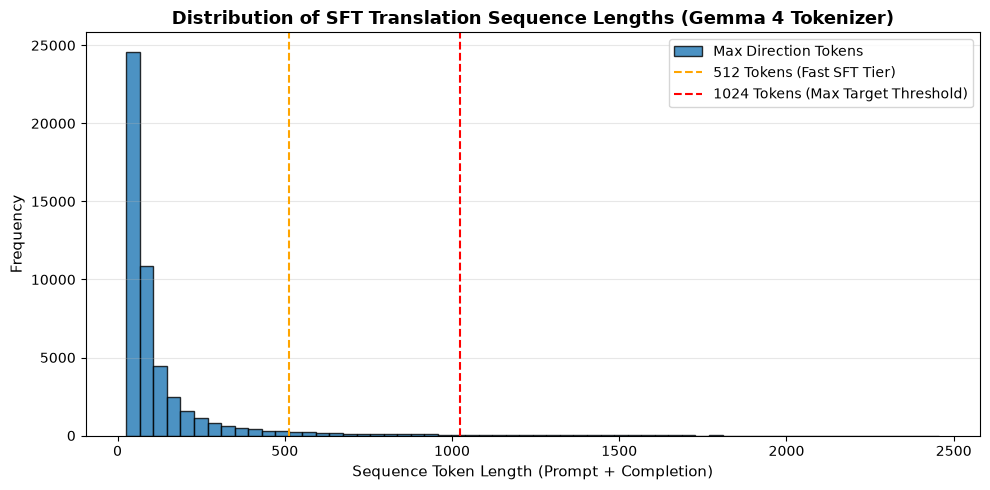

In [11]:
# Visualize token length distribution
fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
ax.hist(df['max_template_tokens'], bins=60, color='#1f77b4', edgecolor='black', alpha=0.8, label='Max Direction Tokens')
ax.axvline(x=512, color='orange', linestyle='--', linewidth=1.5, label='512 Tokens (Fast SFT Tier)')
ax.axvline(x=1024, color='red', linestyle='--', linewidth=1.5, label='1024 Tokens (Max Target Threshold)')
ax.set_title('Distribution of SFT Translation Sequence Lengths (Gemma 4 Tokenizer)', fontsize=13, fontweight='bold')
ax.set_xlabel('Sequence Token Length (Prompt + Completion)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 8. Stage 6: Long Sequence Splitting & Token Compliance

To prevent truncation during training on GPUs with finite VRAM (e.g. 8GB/16GB VRAM, standard target sequence length = 1024 tokens), we split composite long translation examples.

**Splitting Hierarchy**:
1. **Paragraph alignment (`\n\n`)**: If both Arabic and English have matching paragraph counts, split into aligned sub-pairs.
2. **Line alignment (`\n`)**: If both have matching line counts, split into aligned line pairs.
3. **Sentence boundary alignment (`.`, `?`, `!`, `؟`)**: Group aligned sentences into chunks that strictly fit within the target token threshold.
4. **Balanced Recursive Subdivision**: For multi-sentence texts, subdivide proportionally until all child pairs satisfy the token length limit.

In [12]:
MAX_TOKENS_THRESHOLD = 1024

def calc_tokens(en, ar):
    en2dz = f"ترجم الجملة التالية من الإنجليزية إلى الدارجة الجزائرية:\n\n{en}\n\nالترجمة:\n{ar}"
    dz2en = f"Translate the following Algerian Darija sentence to English:\n\n{ar}\n\nTranslation:\n{en}"
    t1 = len(tokenizer.encode(en2dz, add_special_tokens=True))
    t2 = len(tokenizer.encode(dz2en, add_special_tokens=True))
    return max(t1, t2)

def split_parallel_pair(ar_text, en_text, max_thresh=1024):
    # If already compliant, return as single pair
    if calc_tokens(en_text, ar_text) <= max_thresh:
        return [(ar_text, en_text)]
        
    # 1. Paragraph-level alignment (\n\n)
    ar_paras = [p.strip() for p in ar_text.split('\n\n') if p.strip()]
    en_paras = [p.strip() for p in en_text.split('\n\n') if p.strip()]
    if len(ar_paras) == len(en_paras) and len(ar_paras) > 1:
        pairs = []
        for a, e in zip(ar_paras, en_paras):
            pairs.extend(split_parallel_pair(a, e, max_thresh))
        return pairs
        
    # 2. Line-level alignment (\n)
    ar_lines = [p.strip() for p in ar_text.split('\n') if p.strip()]
    en_lines = [p.strip() for p in en_text.split('\n') if p.strip()]
    if len(ar_lines) == len(en_lines) and len(ar_lines) > 1:
        pairs = []
        for a, e in zip(ar_lines, en_lines):
            pairs.extend(split_parallel_pair(a, e, max_thresh))
        return pairs

    # 3. Sentence-level alignment
    ar_sents = [s.strip() for s in re.split(r'(?<=[.!?؟])\s+', ar_text) if s.strip()]
    en_sents = [s.strip() for s in re.split(r'(?<=[.!?])\s+', en_text) if s.strip()]
    if len(ar_sents) == len(en_sents) and len(ar_sents) > 1:
        pairs = []
        cur_ar, cur_en = [], []
        for a, e in zip(ar_sents, en_sents):
            cand_ar = " ".join(cur_ar + [a])
            cand_en = " ".join(cur_en + [e])
            if cur_ar and calc_tokens(cand_en, cand_ar) > max_thresh:
                pairs.append((" ".join(cur_ar), " ".join(cur_en)))
                cur_ar, cur_en = [a], [e]
            else:
                cur_ar.append(a)
                cur_en.append(e)
        if cur_ar:
            pairs.append((" ".join(cur_ar), " ".join(cur_en)))
        return pairs

    # 4. Proportional sentence subdivision
    if len(ar_sents) > 1 and len(en_sents) > 1:
        mid_ar = len(ar_sents) // 2
        mid_en = len(en_sents) // 2
        p1 = split_parallel_pair(" ".join(ar_sents[:mid_ar]), " ".join(en_sents[:mid_en]), max_thresh)
        p2 = split_parallel_pair(" ".join(ar_sents[mid_ar:]), " ".join(en_sents[mid_en:]), max_thresh)
        return p1 + p2

    return [(ar_text, en_text)]

# Process long sequence splitting
print(f"Applying long sequence splitting on threshold = {MAX_TOKENS_THRESHOLD} tokens...")
new_rows = []
split_examples_count = 0

for idx, row in df.iterrows():
    if row['max_template_tokens'] > MAX_TOKENS_THRESHOLD:
        sub_pairs = split_parallel_pair(row['Arabic'], row['English'], max_thresh=MAX_TOKENS_THRESHOLD)
        if len(sub_pairs) > 1:
            split_examples_count += 1
            for p_ar, p_en in sub_pairs:
                new_rows.append({'id': row['id'], 'Arabic': p_ar, 'English': p_en})
        else:
            new_rows.append({'id': row['id'], 'Arabic': row['Arabic'], 'English': row['English']})
    else:
        new_rows.append({'id': row['id'], 'Arabic': row['Arabic'], 'English': row['English']})

df_clean = pd.DataFrame(new_rows)
print(f"✓ Long examples split into multiple sub-segments: {split_examples_count:,}")
print(f"✓ Total dataset size post-splitting:               {len(df_clean):,} rows")

Applying long sequence splitting on threshold = 1024 tokens...
✓ Long examples split into multiple sub-segments: 409
✓ Total dataset size post-splitting:               50,796 rows


In [13]:
# Recompute token lengths for the cleaned dataset
en_clean = df_clean['English'].tolist()
ar_clean = df_clean['Arabic'].tolist()

en2dz_clean = [f"ترجم الجملة التالية من الإنجليزية إلى الدارجة الجزائرية:\n\n{en}\n\nالترجمة:\n{ar}" for en, ar in zip(en_clean, ar_clean)]
dz2en_clean = [f"Translate the following Algerian Darija sentence to English:\n\n{ar}\n\nTranslation:\n{en}" for ar, en in zip(ar_clean, en_clean)]

df_clean['en2dz_tokens'] = compute_token_lengths(en2dz_clean)
df_clean['dz2en_tokens'] = compute_token_lengths(dz2en_clean)
df_clean['max_template_tokens'] = np.maximum(df_clean['en2dz_tokens'], df_clean['dz2en_tokens'])

# Check exceeding counts post-splitting
exceed_final = (df_clean['max_template_tokens'] > MAX_TOKENS_THRESHOLD).sum()
print("="*65)
print("POST-SPLIT TOKEN DISTRIBUTION SUMMARY")
print("="*65)
print(f"Max Token Length in Cleaned Dataset:  {df_clean['max_template_tokens'].max()} tokens")
print(f"Mean Token Length:                   {df_clean['max_template_tokens'].mean():.2f} tokens")
print(f"Median Token Length:                 {df_clean['max_template_tokens'].median():.2f} tokens")
print(f"99th Percentile Token Length:        {df_clean['max_template_tokens'].quantile(0.99):.2f} tokens")
print(f"Examples exceeding {MAX_TOKENS_THRESHOLD} tokens:        {exceed_final} ({exceed_final/len(df_clean)*100:.3f}%)")

POST-SPLIT TOKEN DISTRIBUTION SUMMARY
Max Token Length in Cleaned Dataset:  1024 tokens
Mean Token Length:                   122.49 tokens
Median Token Length:                 68.00 tokens
99th Percentile Token Length:        842.05 tokens
Examples exceeding 1024 tokens:        0 (0.000%)


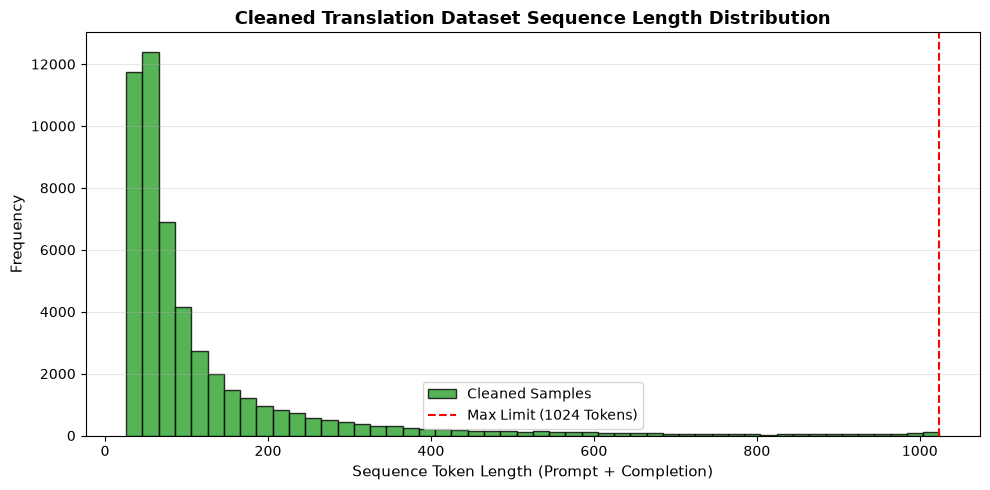

In [14]:
# Plot post-cleaning token length distribution
fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
ax.hist(df_clean['max_template_tokens'], bins=50, color='#2ca02c', edgecolor='black', alpha=0.8, label='Cleaned Samples')
ax.axvline(x=MAX_TOKENS_THRESHOLD, color='red', linestyle='--', linewidth=1.5, label=f'Max Limit ({MAX_TOKENS_THRESHOLD} Tokens)')
ax.set_title('Cleaned Translation Dataset Sequence Length Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Sequence Token Length (Prompt + Completion)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 9. Stage 7: Final Data Quality Verification & Dataset Export

We re-index the dataset, display final audit telemetry, and persist the cleaned translation dataset to disk.

In [15]:
# Re-index unique identifiers
df_clean['id'] = range(len(df_clean))

# Export clean CSV
output_csv = 'algerian_translation_50k_cleaned.csv'
df_export = df_clean[['id', 'Arabic', 'English']]
df_export.to_csv(output_csv, index=False)
print(f"✓ Saved cleaned translation dataset to '{output_csv}' ({len(df_export):,} rows).")

# Comprehensive Pipeline Telemetry Summary
print("\n" + "="*70)
print("           END-TO-END TRANSLATION DATA CLEANING SUMMARY")
print("="*70)
summary_data = [
    ["1. Raw Ingested Pairs", f"{init_rows:,}", "100.00%"],
    ["2. Exact Duplicate Pairs Dropped", f"-{dup_pairs:,}", f"-{dup_pairs/init_rows*100:.2f}%"],
    ["3. Empty Strings Dropped", f"-{empty_count:,}", f"-{empty_count/init_rows*100:.2f}%"],
    ["4. Square Bracket Substrings Stripped", f"{both_bracket.sum():,}", "Paired clean"],
    ["5. Egyptian Inconsistency Corruptions Dropped", f"-{egypt_count:,}", f"-{egypt_count/init_rows*100:.2f}%"],
    ["6. Long Oversized Examples Split", f"+{len(df_clean) - (init_rows - dup_pairs - egypt_count):,}", "Aligned Segments"],
    ["7. Final Clean Translation Dataset", f"{len(df_export):,}", f"{len(df_export)/init_rows*100:.2f}%"]
]

summary_df = pd.DataFrame(summary_data, columns=["Pipeline Stage", "Sample Count", "Impact"])
display(summary_df)

print("\nSample preview of cleaned parallel pairs:")
display(df_export.head(5))

✓ Saved cleaned translation dataset to 'algerian_translation_50k_cleaned.csv' (50,796 rows).

           END-TO-END TRANSLATION DATA CLEANING SUMMARY
                               Pipeline Stage Sample Count           Impact
                        1. Raw Ingested Pairs       50,000          100.00%
             2. Exact Duplicate Pairs Dropped          -94           -0.19%
                     3. Empty Strings Dropped           -0           -0.00%
        4. Square Bracket Substrings Stripped          798     Paired clean
5. Egyptian Inconsistency Corruptions Dropped          -55           -0.11%
             6. Long Oversized Examples Split         +945 Aligned Segments
           7. Final Clean Translation Dataset       50,796          101.59%

Sample preview of cleaned parallel pairs:
   id                                                                                                 Arabic                                                                                           